In [87]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

from pathlib import Path

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

In [88]:
BASE_DIR = Path.cwd().parent

DATA_PROCESSED = BASE_DIR / "data" / "processed"

In [89]:
df = pd.read_csv(
    DATA_PROCESSED / "dataset_scored_v1.csv"
)

print(df.shape)

df.head()

(174, 58)


,codigo_ine,municipio,poblacion_2025,n_poligonos_residenciales,superficie_residencial_m2,superficie_residencial_ha,superficie_media_poligono_m2,superficie_mediana_poligono_m2,superficie_max_poligono_m2,perimetro_total_m,suelo_residencial_m2_por_hab,municipio_key,area_m2_SUNC,area_m2_Urbanizable,area_m2_desarrollo,sunc_m2_por_hab,urbanizable_m2_por_hab,comarca,precio_venta_eur_m2,precio_alquiler_eur_m2_mes,poblacion_aprox,tipo_dato,fuente,fecha,reserva_suelo_hab,indice_expansion,densidad_residencial,poblacion_2025_norm,precio_venta_eur_m2_norm,precio_alquiler_eur_m2_mes_norm,suelo_residencial_m2_por_hab_norm,reserva_suelo_hab_norm,indice_expansion_norm,densidad_residencial_norm,precio_venta_score,precio_alquiler_score,coopscore,factor_escala,distancia_capital_km,distancia_costa_km,score_poblacion,score_suelo_residencial,score_reserva_suelo,score_expansion,score_densidad,score_precio_venta,score_precio_alquiler,IVU,IVEC,score_demanda_poblacion,score_demanda_alquiler,score_demanda_venta,IPD,score_capital,score_costa,score_litoral,IAL,CoopScore_4
0,18905,"Gabias, Las",23584,1.0,3.682035e+06,368.203480,3.682035e+06,3.682035e+06,3.682035e+06,40983.790385,156.124271,LAS GABIAS,NaN,NaN,0.000000e+00,NaN,NaN,Área Metropolitana,1601.0,8.40,25600.0,V,Idealista/Indomio/Fotocasa 2026,2026-05,0.000000,0.000000,64.051540,0.100263,0.437668,0.573858,0.098990,0.000000,0.000000,0.065191,0.562332,0.426142,13.572044,1.00,56.02,66.9,0.100263,0.098990,0.000000,0.000000,0.065191,0.562332,0.573858,3.452622,30.756813,0.100263,0.573858,0.437668,30.301264,0.661367,0.693541,0,0.472609,16.543829
1,18089,Guadix,18881,7.0,3.460928e+06,346.092770,4.944182e+05,1.185983e+05,2.848796e+06,43493.539742,183.302140,GUADIX,438023.0,3.532430e+05,7.912660e+05,23.199142,18.708914,Comarca de Guadix,839.0,NaN,18800.0,V,Idealista/Indomio/Fotocasa 2026,2026-05,41.908056,0.228628,54.554737,0.080150,0.145378,NaN,0.117566,0.022179,0.022938,0.054381,0.854622,NaN,NaN,1.00,52.61,91.1,0.080150,0.117566,0.022179,0.022938,0.054381,0.854622,0.599362,5.108377,36.227069,0.080150,0.599362,0.145378,22.626015,0.681980,0.582684,0,0.447597,16.568343
2,18022,Atarfe,20914,1.0,3.364040e+06,336.403955,3.364040e+06,3.364040e+06,3.364040e+06,37294.919233,160.851083,ATARFE,33512.0,3.636106e+06,3.669618e+06,1.602372,173.859902,Vega de Granada,1380.0,NaN,17300.0,V,Idealista/Indomio/Fotocasa 2026,2026-05,175.462274,1.090837,62.169305,0.088844,0.352896,NaN,0.102221,0.092858,0.109444,0.063049,0.647104,NaN,NaN,1.00,10.45,108.3,0.088844,0.102221,0.092858,0.109444,0.063049,0.647104,0.599362,9.570330,32.554620,0.088844,0.599362,0.352896,28.248677,0.936831,0.503894,0,0.525901,18.629325
3,18029,Benamaurel,2235,9.0,3.295178e+06,329.517829,3.661309e+05,1.089552e+05,1.376323e+06,32558.922141,1474.352704,BENAMAUREL,30085.0,4.464030e+05,4.764880e+05,13.460850,199.732886,Comarca de Baza,510.0,NaN,1800.0,E,Estimación por comarca/tipología,2026-05,213.193736,0.144602,6.782638,0.008964,0.019179,NaN,1.000000,0.112827,0.014508,0.000000,0.980821,NaN,NaN,0.85,109.41,36.8,0.008964,1.000000,0.112827,0.014508,0.000000,0.980821,0.599362,28.820041,35.003836,0.008964,0.599362,0.019179,15.911715,0.338633,0.831425,40,12.384880,20.972589
4,18003,Albolote,19768,1.0,2.949836e+06,294.983553,2.949836e+06,2.949836e+06,2.949836e+06,42092.590074,149.222761,ALBOLOTE,828396.0,2.047817e+06,2.876213e+06,41.905909,103.592530,Área Metropolitana,1622.0,8.88,19800.0,V,Idealista/Indomio/Fotocasa 2026,2026-05,145.498439,0.975042,67.013906,0.083943,0.445723,0.624867,0.094273,0.077001,0.097826,0.068563,0.554277,0.375133,13.961871,1.00,9.78,71.1,0.083943,0.094273,0.077001,0.097826,0.068563,0.554277,0.624867,8.630095,31.170308,0.083943,0.624867,0.445723,30.961928,0.940881,0.674301,0,0.578643,18.640389


In [90]:
geo = gpd.read_file(
    "../data/external/municipios_granada.geojson"
)

print(geo.shape)

geo.head()

(174, 8)


,nombre,nombre_local,codigo_ine,provincia,codigo_provincia,comunidad_autonoma,tipo,geometry
0,Domingo Pérez de Granada,None,18915,Granada,18,Andalucía,municipality,"POLYGON ((-3.56828 37.53316, -3.57064 37.53057..."
1,Cuevas del Campo,None,18912,Granada,18,Andalucía,municipality,"POLYGON ((-2.97818 37.60275, -2.97985 37.60217..."
2,Guadahortuna,None,18088,Granada,18,Andalucía,municipality,"POLYGON ((-3.47548 37.5409, -3.47203 37.53105,..."
3,Íllora,None,18102,Granada,18,Andalucía,municipality,"POLYGON ((-3.99129 37.2494, -3.99027 37.24847,..."
4,Albuñán,None,18005,Granada,18,Andalucía,municipality,"POLYGON ((-3.15288 37.20768, -3.15105 37.20636..."


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 58 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   codigo_ine                         174 non-null    int64  
 1   municipio                          174 non-null    object 
 2   poblacion_2025                     174 non-null    int64  
 3   n_poligonos_residenciales          128 non-null    float64
 4   superficie_residencial_m2          128 non-null    float64
 5   superficie_residencial_ha          128 non-null    float64
 6   superficie_media_poligono_m2       128 non-null    float64
 7   superficie_mediana_poligono_m2     128 non-null    float64
 8   superficie_max_poligono_m2         128 non-null    float64
 9   perimetro_total_m                  128 non-null    float64
 10  suelo_residencial_m2_por_hab       128 non-null    float64
 11  municipio_key                      174 non-null    object 

In [92]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
codigo_ine,174.0,18170.827586,241.547573,18001.000000,18050.250000,18105.500000,18160.500000,1.891600e+04
poblacion_2025,174.0,5417.344828,18795.385635,139.000000,618.250000,1199.000000,3965.750000,2.339750e+05
n_poligonos_residenciales,128.0,2.695312,3.018470,1.000000,1.000000,1.000000,3.000000,1.900000e+01
superficie_residencial_m2,128.0,660316.636867,778363.600717,26728.025444,201842.356236,364206.952579,735784.818071,3.682035e+06
superficie_residencial_ha,128.0,66.031664,77.836360,2.672803,20.184236,36.420695,73.578482,3.682035e+02
superficie_media_poligono_m2,128.0,389948.404700,599636.438929,10786.189235,98219.581567,185163.369796,372784.794560,3.682035e+06
superficie_mediana_poligono_m2,128.0,360830.229406,608071.930595,3237.327634,63434.377482,139947.779912,360851.311031,3.682035e+06
superficie_max_poligono_m2,128.0,540203.852210,664178.653507,22338.454589,163799.793008,268587.641043,631465.931232,3.682035e+06
perimetro_total_m,128.0,12582.840865,11409.306398,1185.382465,4574.566409,8328.062894,15706.375735,5.460758e+04
suelo_residencial_m2_por_hab,128.0,251.216743,172.447139,11.296156,145.161183,210.454256,315.595142,1.474353e+03


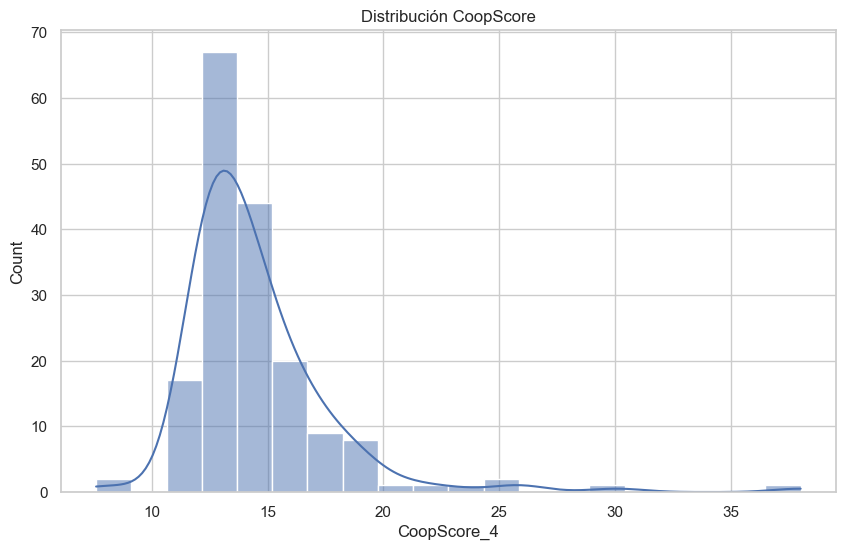

In [93]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["CoopScore_4"],
    bins=20,
    kde=True
)

plt.title("Distribución CoopScore")
plt.show()

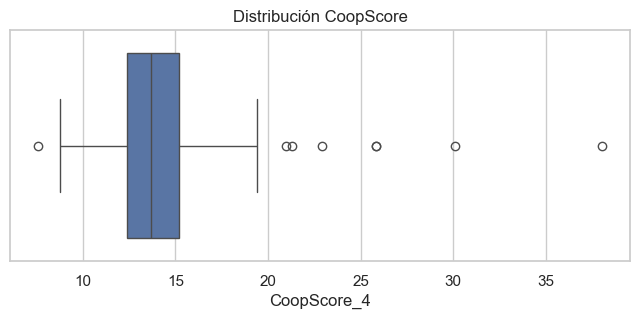

In [94]:
plt.figure(figsize=(8,3))

sns.boxplot(
    x=df["CoopScore_4"]
)

plt.title("Distribución CoopScore")
plt.show()

In [95]:
top20 = (
    df
    .sort_values(
        "CoopScore_4",
        ascending=False
    )
    .head(20)
)

top20[
    [
        "municipio",
        "CoopScore_4"
    ]
]

,municipio,CoopScore_4
141,Granada,38.029727
68,Pinos Genil,30.077779
37,Motril,25.840709
153,Monachil,25.814776
12,Almuñécar,22.934893
6,Salobreña,21.294396
3,Benamaurel,20.972589
19,Maracena,19.405385
120,Diezma,19.364972
147,Huétor Vega,19.118986


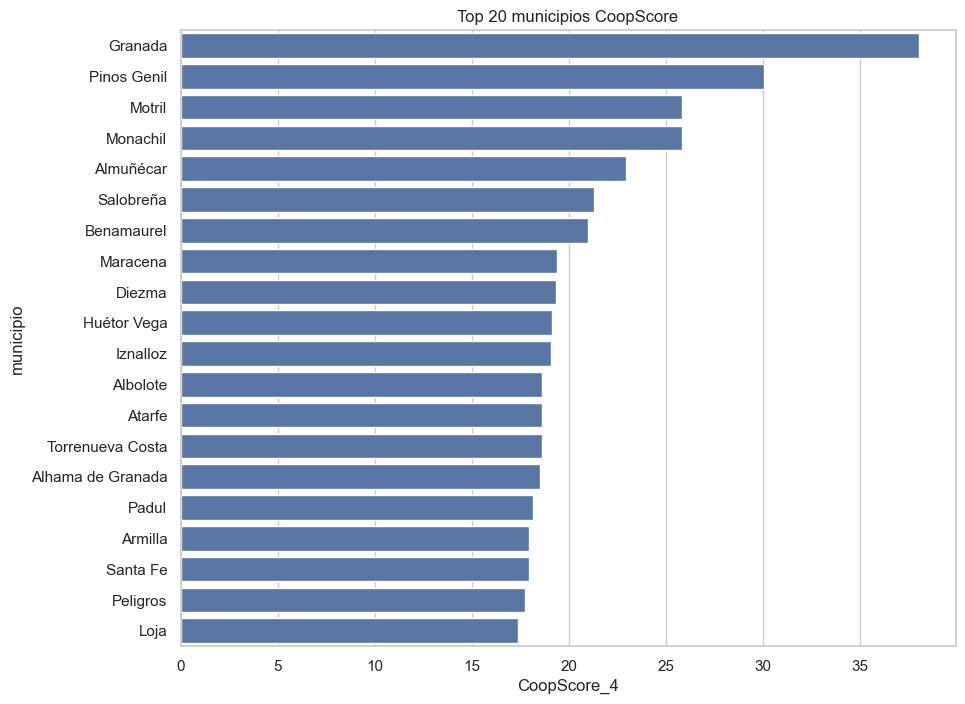

In [96]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=top20,
    x="CoopScore_4",
    y="municipio"
)

plt.title("Top 20 municipios CoopScore")

plt.show()

In [97]:
(
    df
    .sort_values(
        "IVU",
        ascending=False
    )
    [["municipio","IVU"]]
    .head(15)
)

,municipio,IVU
68,Pinos Genil,63.831306
3,Benamaurel,28.820041
120,Diezma,22.425645
124,Torrenueva Costa,20.536196
37,Motril,15.272837
25,Cortes de Baza,13.313255
41,Orce,11.975851
92,Aldeire,11.560693
73,Alquife,11.158738
113,Calicasas,10.976739


In [98]:
(
    df
    .sort_values(
        "IVEC",
        ascending=False
    )
    [["municipio","IVEC"]]
    .head(15)
)

,municipio,IVEC
141,Granada,77.954460
37,Motril,46.336164
124,Torrenueva Costa,39.773092
8,Baza,38.405513
153,Monachil,37.568395
5,Loja,37.350588
173,"Zubia, La",36.851422
7,Íllora,36.531838
1,Guadix,36.227069
46,Puebla de Don Fadrique,35.594784


In [99]:
(
    df
    .sort_values(
        "IAL",
        ascending=False
    )
    [["municipio","IAL"]]
    .head(15)
)

,municipio,IAL
153,Monachil,30.658166
80,Cacín,30.583042
170,Vélez de Benaudalla,30.561999
6,Salobreña,30.526030
117,Torvizcón,30.508966
22,Caniles,30.434881
100,Murtas,30.376407
148,Jun,21.668864
64,Güevéjar,21.661646
147,Huétor Vega,21.642697


In [100]:
(
    df
    .sort_values(
        "IPD",
        ascending=False
    )
    [["municipio","IPD"]]
    .head(15)
)

,municipio,IPD
141,Granada,68.100669
12,Almuñécar,51.582512
153,Monachil,38.742690
9,Armilla,37.469372
37,Motril,35.409509
6,Salobreña,35.331777
11,Churriana de la Vega,32.826102
4,Albolote,30.961928
0,"Gabias, Las",30.301264
19,Maracena,30.133901


In [101]:
numericas = df.select_dtypes(
    include=np.number
)

corr = numericas.corr()

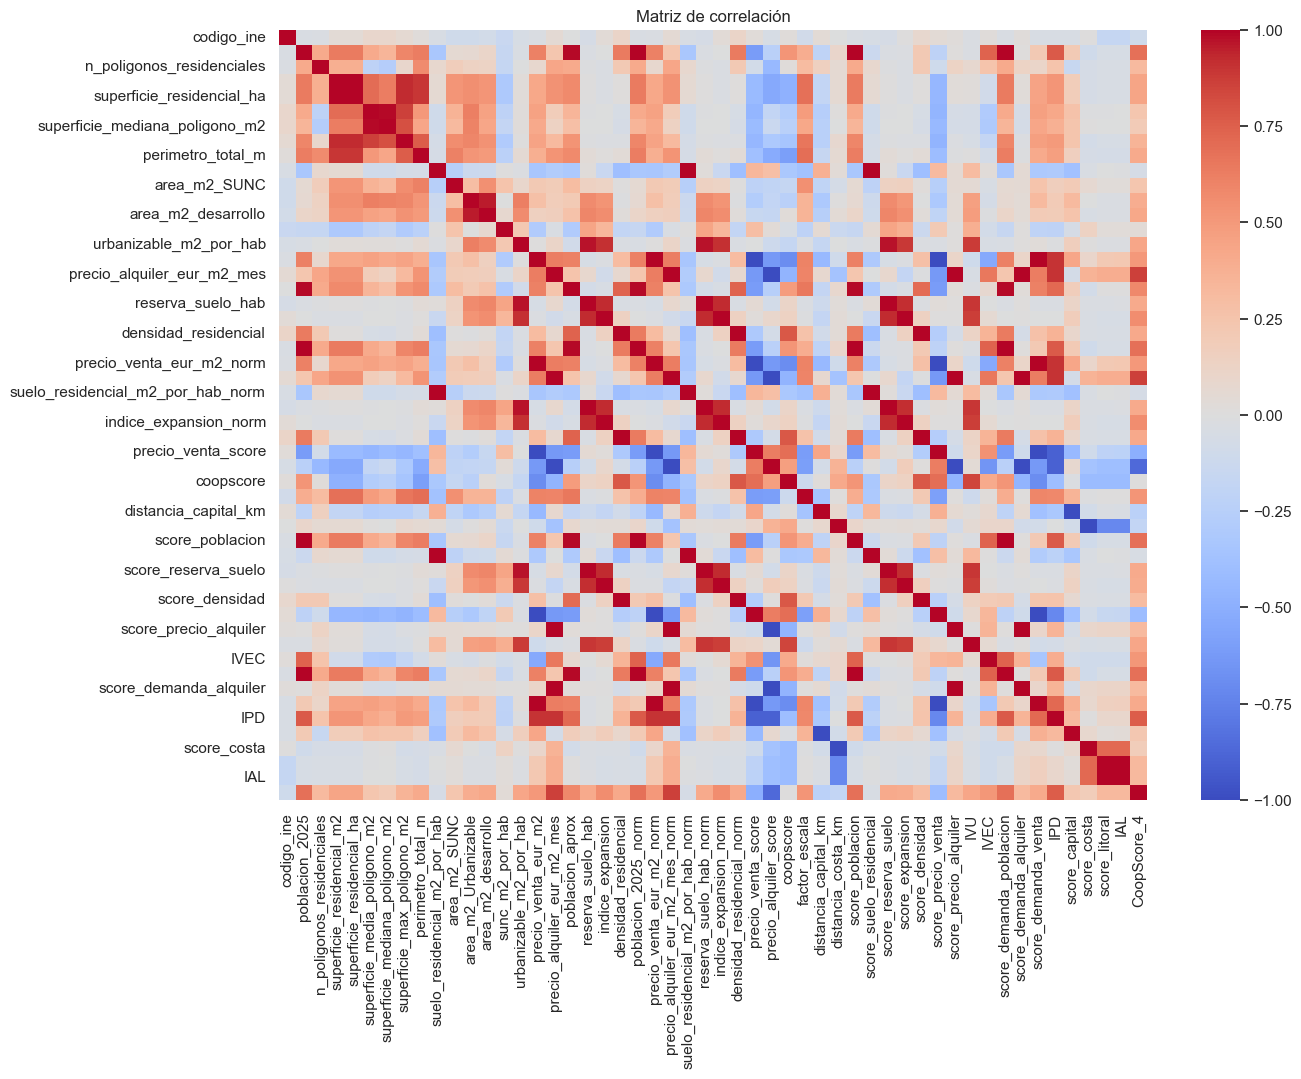

In [102]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación")

plt.show()

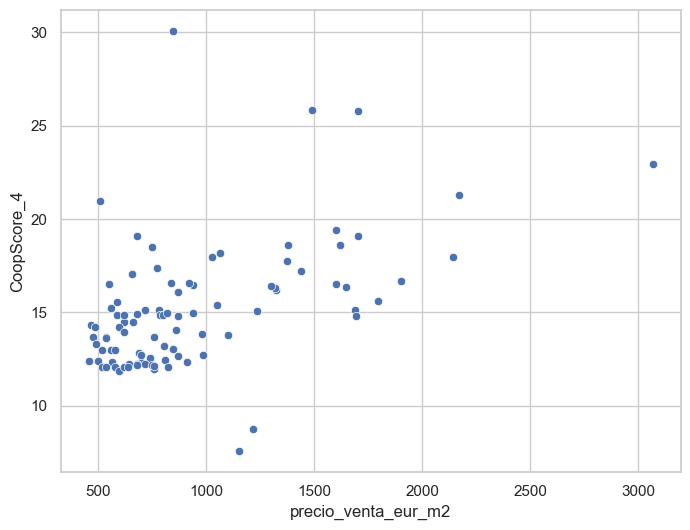

In [103]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="precio_venta_eur_m2",
    y="CoopScore_4"
)

plt.show()

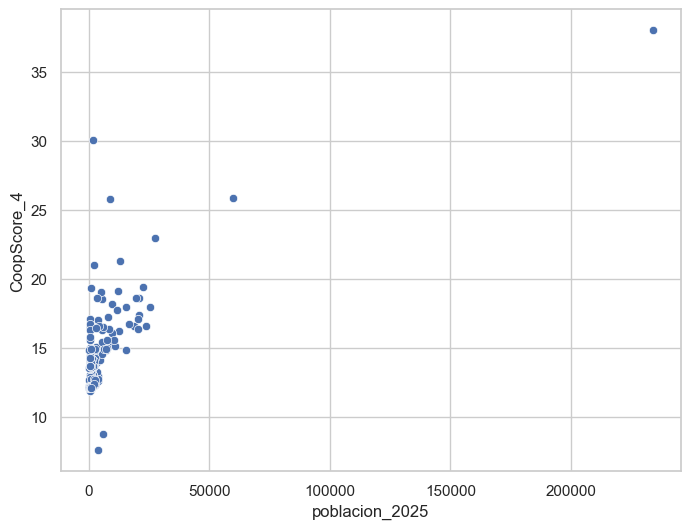

In [104]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="poblacion_2025",
    y="CoopScore_4"
)

plt.show()

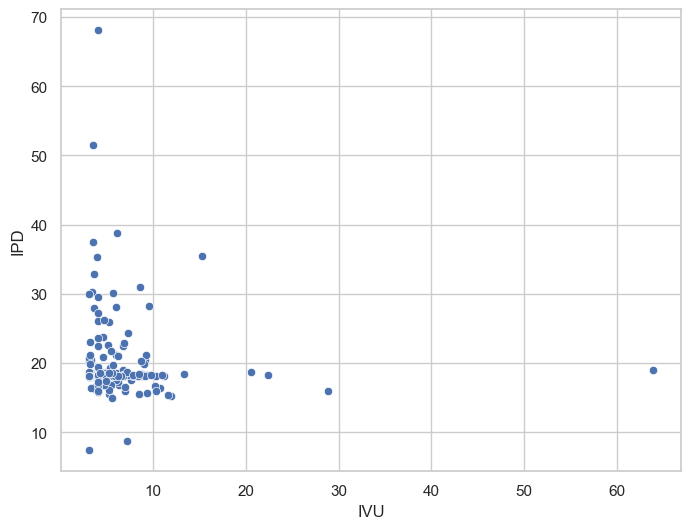

In [105]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="IVU",
    y="IPD"
)

plt.show()

In [106]:
municipios_clave = [
    "Granada",
    "Motril",
    "Salobreña",
    "Almuñécar",
    "Baza",
    "Loja"
]

df[
    df["municipio"].isin(
        municipios_clave
    )
][[
    "municipio",
    "IVU",
    "IVEC",
    "IAL",
    "IPD",
    "CoopScore_4"
]].sort_values(
    "CoopScore_4",
    ascending=False
)

,municipio,IVU,IVEC,IAL,IPD,CoopScore_4
141,Granada,4.098648,77.954460,0.542785,68.100669,38.029727
37,Motril,15.272837,46.336164,0.391987,35.409509,25.840709
12,Almuñécar,3.515383,27.766946,12.447634,51.582512,22.934893
6,Salobreña,3.960215,25.985888,30.526030,35.331777,21.294396
5,Loja,6.755890,37.350588,0.427879,22.426132,17.372923
8,Baza,6.049793,38.405513,0.318408,21.235910,17.075545


In [107]:
# ============================================================
# CLASIFICACIÓN ESTRATÉGICA MUNICIPAL
# ============================================================

mediana_ivu = df["IVU"].median()
mediana_ipd = df["IPD"].median()

def clasificar_municipio(row):

    if row["IVU"] >= mediana_ivu and row["IPD"] >= mediana_ipd:
        return "Oportunidad Estratégica"

    elif row["IVU"] >= mediana_ivu:
        return "Potencial Urbanístico"

    elif row["IPD"] >= mediana_ipd:
        return "Potencial Económico"

    else:
        return "Mercado Maduro"

df["categoria_coopscore"] = df.apply(
    clasificar_municipio,
    axis=1
)

df[
    [
        "municipio",
        "categoria_coopscore"
    ]
].head()

,municipio,categoria_coopscore
0,"Gabias, Las",Potencial Económico
1,Guadix,Oportunidad Estratégica
2,Atarfe,Oportunidad Estratégica
3,Benamaurel,Potencial Urbanístico
4,Albolote,Oportunidad Estratégica


In [108]:
df["categoria_coopscore"].value_counts()

categoria_coopscore
Oportunidad Estratégica    45
Mercado Maduro             45
Potencial Económico        42
Potencial Urbanístico      42
Name: count, dtype: int64

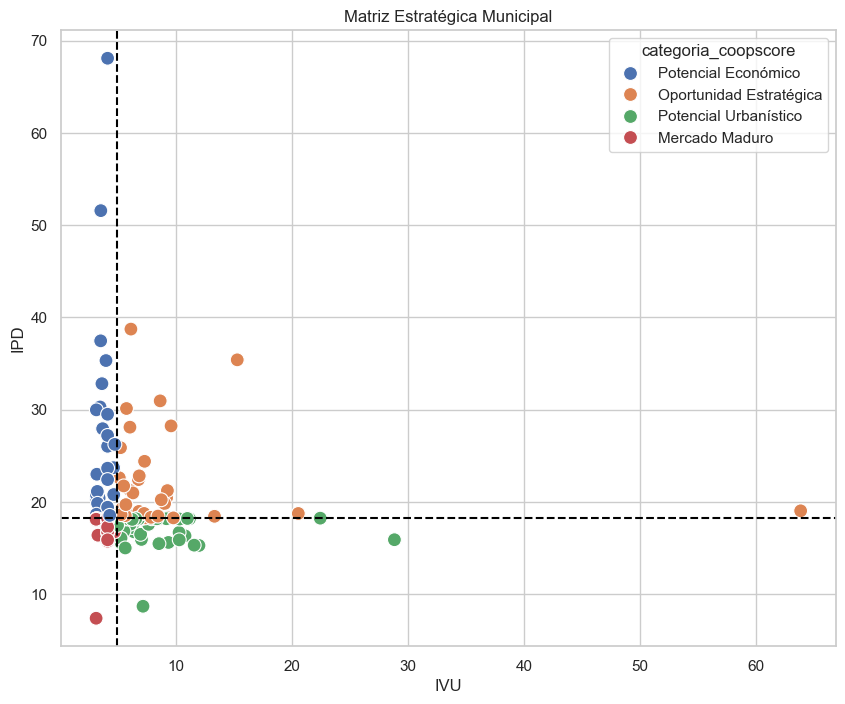

In [109]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=df,
    x="IVU",
    y="IPD",
    hue="categoria_coopscore",
    s=100
)

plt.axvline(
    mediana_ivu,
    linestyle="--",
    color="black"
)

plt.axhline(
    mediana_ipd,
    linestyle="--",
    color="black"
)

plt.title(
    "Matriz Estratégica Municipal"
)

plt.show()

In [110]:
df[
    df["categoria_coopscore"] ==
    "Oportunidad Estratégica"
][[
    "municipio",
    "CoopScore_4",
    "IVU",
    "IPD"
]].sort_values(
    "CoopScore_4",
    ascending=False
).head(20)

,municipio,CoopScore_4,IVU,IPD
68,Pinos Genil,30.077779,63.831306,19.045370
37,Motril,25.840709,15.272837,35.409509
153,Monachil,25.814776,6.109372,38.742690
19,Maracena,19.405385,5.726328,30.133901
4,Albolote,18.640389,8.630095,30.961928
2,Atarfe,18.629325,9.570330,28.248677
124,Torrenueva Costa,18.607353,20.536196,18.756684
29,Alhama de Granada,18.499425,5.496459,18.949527
14,Padul,18.180199,6.825119,22.832662
5,Loja,17.372923,6.755890,22.426132


In [111]:
df[
    df["categoria_coopscore"] ==
    "Potencial Urbanístico"
][[
    "municipio",
    "CoopScore_4",
    "IVU"
]].sort_values(
    "IVU",
    ascending=False
).head(20)

,municipio,CoopScore_4,IVU
3,Benamaurel,20.972589,28.820041
120,Diezma,19.364972,22.425645
41,Orce,14.332814,11.975851
92,Aldeire,14.212385,11.560693
73,Alquife,14.190533,11.158738
113,Calicasas,14.269003,10.976739
72,Arenas del Rey,15.551292,10.773297
87,Dehesas de Guadix,13.902154,10.303145
97,Gorafe,16.499792,10.276061
79,Jayena,13.950995,10.259253


In [112]:
df.to_csv(
    DATA_PROCESSED / "dataset_scored_final.csv",
    index=False
)

In [113]:
df[
    df["categoria_coopscore"] ==
    "Potencial Económico"
][[
    "municipio",
    "CoopScore_4",
    "IPD"
]].sort_values(
    "IPD",
    ascending=False
).head(20)

,municipio,CoopScore_4,IPD
141,Granada,38.029727,68.100669
12,Almuñécar,22.934893,51.582512
9,Armilla,17.968997,37.469372
6,Salobreña,21.294396,35.331777
11,Churriana de la Vega,16.692759,32.826102
0,"Gabias, Las",16.543829,30.301264
20,Alhendín,15.590952,29.986637
147,Huétor Vega,19.118986,29.510600
24,Cájar,15.132813,27.947074
155,Ogíjares,14.829657,27.213212


In [114]:
ranking = (
    df
    .sort_values(
        "CoopScore_4",
        ascending=False
    )
)

In [115]:
ranking.to_csv(
    DATA_PROCESSED / "ranking_coopscore_v1.csv",
    index=False
)

In [116]:
ranking.head(20).to_csv(
    DATA_PROCESSED / "top20_coopscore.csv",
    index=False
)

In [117]:
geo["codigo_ine"] = (
    geo["codigo_ine"]
    .astype(str)
    .str.zfill(5)
)

df["codigo_ine"] = (
    df["codigo_ine"]
    .astype(str)
    .str.zfill(5)
)

In [118]:
mapa = geo.merge(
    df,
    on="codigo_ine",
    how="left"
)

print(mapa.shape)

(174, 66)


In [119]:
mapa["CoopScore_4"].isna().sum()

np.int64(0)

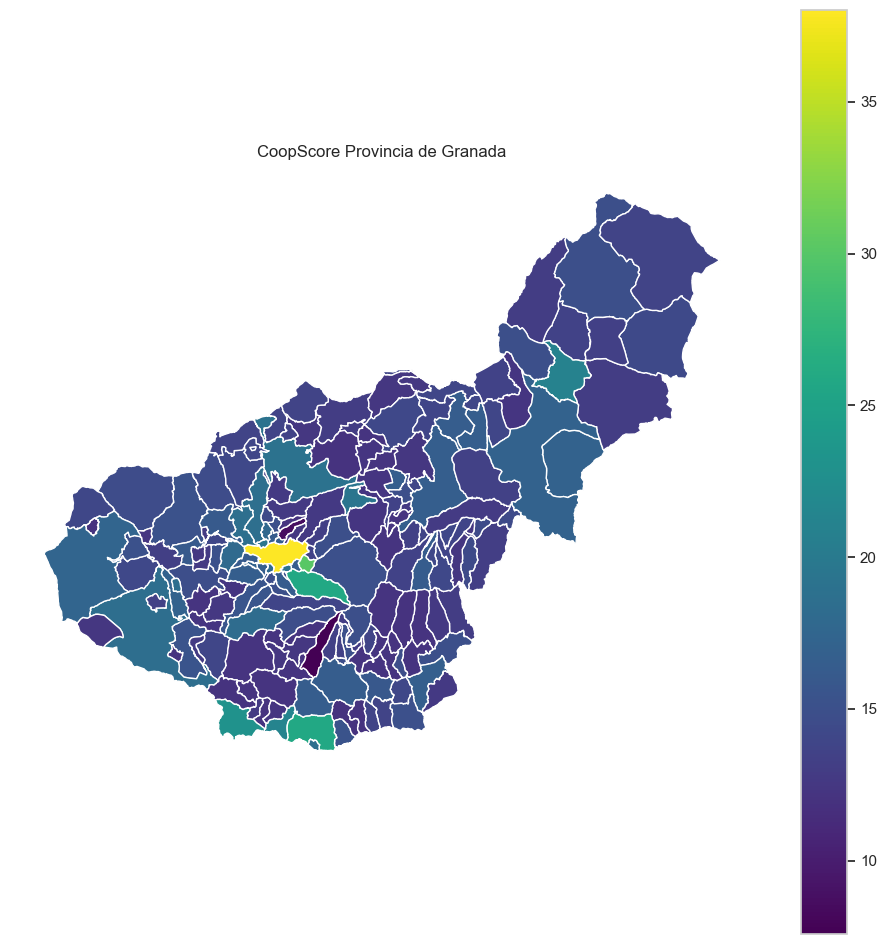

In [120]:
fig, ax = plt.subplots(
    figsize=(12,12)
)

mapa.plot(
    column="CoopScore_4",
    cmap="viridis",
    legend=True,
    ax=ax
)

ax.set_title(
    "CoopScore Provincia de Granada"
)

ax.axis("off")

plt.show()

In [121]:
print(df.shape)

print(df["CoopScore_4"].isna().sum())

print(df["categoria_coopscore"].value_counts())

(174, 59)
0
categoria_coopscore
Oportunidad Estratégica    45
Mercado Maduro             45
Potencial Económico        42
Potencial Urbanístico      42
Name: count, dtype: int64


In [122]:
df.to_csv(
    DATA_PROCESSED / "dataset_scored_final.csv",
    index=False
)

In [123]:
mapa.to_file(
    DATA_PROCESSED / "municipios_granada_coopscore.geojson",
    driver="GeoJSON"
)